In [86]:
import json
import sys
import pandas as pd
import collections 
import os
import numpy as np
from itertools import chain
from itertools import combinations
sys.path.insert(0, '..')
from src.experiment_utils.helper_classes import token, span, repository
from src.d02_corpus_statistics.corpus import Corpus
import types
from owlready2 import sync_reasoner
from collections import Counter
from transformers import pipeline
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, AutoModelForTokenClassification
import spacy
from spacy.training import offsets_to_biluo_tags
from datasets import Dataset, DatasetDict

cwd = os.getcwd()
pol_dir = cwd+"/../src/d01_data"

In [2]:
pol_df = pd.read_pickle(pol_dir+"/preprocessed_dataframe.pkl")[["Policy","Text","Tokens","Curation"]]

## BILOU

In [57]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
doc = nlp("I like London.")
entities = [(7, 13, "LOC")]
tags = offsets_to_biluo_tags(doc, entities)
tags

In [68]:
pol_df.loc["EU_32018R1999_Title_0_Chapter_7_Section_3_Article_43", "Curation"]

[span id:CUR0 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:64 stop:78 text:delegated acts,
 span id:CUR1 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:188 stop:202 text:delegated acts,
 span id:CUR2 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1227 stop:1241 text:delegated acts,
 span id:CUR3 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1284 stop:1297 text:delegated act,
 span id:CUR4 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1516 stop:1529 text:delegated act,
 span id:CUR5 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1632 stop:1645 text:delegated act,
 span id:CUR6 annotator:Curation layer:Policydesigncharacteristics feature:Actor tag:Authority_legislative start:99 stop:109 text:commission,
 span id:CUR7 annotator:Curation layer:Policydesign

In [90]:
pol_df['Curation'][0]#.loc["EU_32018R1999_Title_0_Chapter_7_Section_3_Article_43"]

C:\Users\allie\AppData\Local\Temp\ipykernel_15436\3212793776.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pol_df['Curation'][0]#.loc["EU_32018R1999_Title_0_Chapter_7_Section_3_Article_43"]


[span id:CUR0 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:64 stop:78 text:delegated acts,
 span id:CUR1 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:188 stop:202 text:delegated acts,
 span id:CUR2 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1227 stop:1241 text:delegated acts,
 span id:CUR3 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1284 stop:1297 text:delegated act,
 span id:CUR4 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1516 stop:1529 text:delegated act,
 span id:CUR5 annotator:Curation layer:Instrumenttypes feature:InstrumentType tag:Unspecified start:1632 stop:1645 text:delegated act,
 span id:CUR6 annotator:Curation layer:Policydesigncharacteristics feature:Actor tag:Authority_legislative start:99 stop:109 text:commission,
 span id:CUR7 annotator:Curation layer:Policydesign

In [ ]:
# using spacy, meh
ds = []
for artid in list(pol_df.index):#["EU_32018R1999_Title_0_Chapter_7_Section_3_Article_43"]:#
    if len(pol_df.loc[artid, "Text"]) > 512:
        doc = nlp(pol_df.loc[artid, "Text"])
        for spanitm in pol_df.loc[artid, "Curation"]:
            if spanitm.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                #if spanitm.feature not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                actor_ents = []
                if spanitm.feature == 'Actor':
                    spanent = (spanitm.start, spanitm.stop, spanitm.feature)
                    if spanent not in entities:
                        actor_ents.append((spanitm.start, spanitm.stop, spanitm.feature))
                obj_ents = []
                if spanitm.feature == 'Objective':
                    spanent = (spanitm.start, spanitm.stop, spanitm.feature)
                    if spanent not in entities:
                        obj_ents.append((spanitm.start, spanitm.stop, spanitm.feature))
                inst_ents = []
                if spanitm.feature == 'InstrumentType':
                    spanent = (spanitm.start, spanitm.stop, spanitm.feature)
                    if spanent not in entities:
                        inst_ents.append((spanitm.start, spanitm.stop, spanitm.feature))
        #try:
        act_tags = offsets_to_biluo_tags(doc, actor_ents)
        obj_tags = offsets_to_biluo_tags(doc, obj_ents)
        inst_tags = offsets_to_biluo_tags(doc, inst_ents)
        ds.append({
            'id':artid,
            
        })
        #except Exception as ValueError:
        #    print("Couldnt get", artid)

In [93]:
model_name = "microsoft/deberta-v3-base"   # any token-classification backbone
tokenizer = AutoTokenizer.from_pretrained(model_name)

def extract_all_labels(df):
    labels = set()
    for spancoll in df["Curation"]:
        for spn in spancoll:
            if spn.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                ftr = spn.feature
                if ftr not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                    label = ftr
                    labels.add(label)
    bio_labels = ["O"]
    for l in sorted(labels):
        bio_labels.append(f"B-{l}")
        bio_labels.append(f"I-{l}")
    return bio_labels

def align_labels_to_tokens(text, tokens, spans, label2id):
    token_labels = ["O"] * len(tokens)
    for spn in spans:
        if spn.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                ftr = spn.feature
                if ftr not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                    start_char = spn.start
                    end_char = spn.stop
                    #
                    inside_tokens = []
                    for i, tok in enumerate(tokens):
                        tok_start = tok.start
                        tok_end = tok.stop
                        overlap = not (tok_end <= start_char or tok_start >= end_char)
                        if overlap:
                            inside_tokens.append(i)
                    if inside_tokens:
                        token_labels[inside_tokens[0]] = f"B-{ftr}"
                        for i in inside_tokens[1:]:
                            token_labels[i] = f"I-{ftr}"
    return [label2id[l] for l in token_labels]


def convert_dataframe(df):
    label_list = extract_all_labels(df)
    label2id = {l: i for i, l in enumerate(label_list)}

    processed = {
        "text": [],
        "tokens": [],
        "input_ids": [],
        "attention_mask": [],
        "labels": [],
    }

    for _, row in df.iterrows():
        text = row["Text"]
        tokens = row["Tokens"]
        spans = row["Curation"]

        token_texts = [t.text for t in tokens]

        # Tokenize using "is_split_into_words=True"
        enc = tokenizer(
            token_texts,
            is_split_into_words=True,
            truncation=True,
            return_offsets_mapping=False,
        )

        # Get per-original-token label IDs
        token_level_labels = align_labels_to_tokens(text, tokens, spans, label2id)

        # Expand labels to subword tokens
        word_ids = enc.word_ids()
        final_labels = []
        for w in word_ids:
            if w is None:
                final_labels.append(-100)
            else:
                final_labels.append(token_level_labels[w])

        processed["text"].append(text)
        processed["tokens"].append(token_texts)
        processed["input_ids"].append(enc["input_ids"])
        processed["attention_mask"].append(enc["attention_mask"])
        processed["labels"].append(final_labels)

    return Dataset.from_dict(processed), label_list


In [95]:
dataset, label_list = convert_dataframe(pol_df)

dataset_dict = DatasetDict({"train": dataset})
dataset_dict.save_to_disk("ner_tokenclass_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/448 [00:00<?, ? examples/s]

In [96]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'tokens', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 448
    })
})

## OFFSET

In [3]:
ner_lst = []
for artid in list(pol_df.index):
    # will remove later when we bring in chunking, but for now let's just play with the short articles
    if len(pol_df.loc[artid, "Text"]) > 512:
        entry = {
            "art_id": artid,
            "text": pol_df.loc[artid, "Text"],
            "entities":[]
        }
        for span in pol_df.loc[artid, "Curation"]:
            if span.layer in ["Instrumenttypes", "Policydesigncharacteristics"]:
                if span.feature not in ["Compliance","Reversibility", "Reference", "InstrumentType_2", "end"]:
                    entry['entities'].append({
                        "start": span.start,
                        "stop": span.stop,
                        "feature": span.feature,
                        "tag": span.tag,
                        "span_id": f"{artid}_{span.span_id}",
                        "text": span.text
                    })
        ner_lst.append(entry)

12 15348 588.7321428571429 267.0


(array([327.,  76.,  21.,   5.,   7.,   2.,   0.,   1.,   1.,   1.,   0.,
          1.,   1.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([1.20000000e+01, 5.40827586e+02, 1.06965517e+03, 1.59848276e+03,
        2.12731034e+03, 2.65613793e+03, 3.18496552e+03, 3.71379310e+03,
        4.24262069e+03, 4.77144828e+03, 5.30027586e+03, 5.82910345e+03,
        6.35793103e+03, 6.88675862e+03, 7.41558621e+03, 7.94441379e+03,
        8.47324138e+03, 9.00206897e+03, 9.53089655e+03, 1.00597241e+04,
        1.05885517e+04, 1.11173793e+04, 1.16462069e+04, 1.21750345e+04,
        1.27038621e+04, 1.32326897e+04, 1.37615172e+04, 1.42903448e+04,
        1.48191724e+04, 1.53480000e+04]),
 <BarContainer object of 29 artists>)

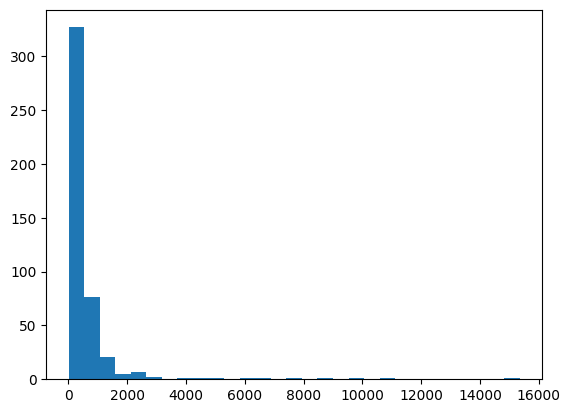

In [4]:
tokens_per_art = []
for artid in list(pol_df.index):
    tokens_per_art.append(len(pol_df.loc[artid, "Tokens"]))
print(np.min(tokens_per_art), np.max(tokens_per_art), np.mean(tokens_per_art), np.median(tokens_per_art))
import matplotlib.pyplot as plt
plt.hist(tokens_per_art, bins=int(15348/512))
#plt.hist(tokens_per_art, bins=int(15348/1024))
#plt.ylim(0,25)

In [5]:
articles = [entry["text"] for entry in ner_lst]
entity_lists = [entry["entities"] for entry in ner_lst]
print(len(articles),len(entity_lists))
#
feature_names = []
for entity_coll in entity_lists:
    for entity in entity_coll:
        feature_names.append(entity['feature'])
Counter(feature_names)

360 360


Counter({'Actor': 5878,
         'InstrumentType': 3320,
         'Objective': 973,
         'Time': 743,
         'Resource': 506})

In [9]:
from sklearn.model_selection import train_test_split
art_tr, art_test, el_tr, el_test = train_test_split(articles, entity_lists, test_size=0.2, random_state=0)
art_train, art_dev, el_train, el_dev = train_test_split(art_tr, el_tr, test_size=0.25, random_state=0)

Experiment with 

FacebookAI/xlm-roberta-base

microsoft/deberta-v3-base   #potential

dslim/bert-base-NER (doesnt work)

dslim/bert-base-NER-uncased

mawaskow/inc_sent_cls_[bn/mc]

Babelscape/rebel-large

Babelscape/mrebel-large

sentence-transformers/gtr-t5-base   #potential

BART
T5 linearization

spaCy: en_core_web_trf

BertForTokenClassification


### Babelscape/mrebel-large

kinda worked but not really

How-to-use from https://huggingface.co/Babelscape/mrebel-large

In [ ]:
triplet_extractor = pipeline('translation_xx_to_yy', model='Babelscape/mrebel-large', tokenizer='Babelscape/mrebel-large')

Device set to use cuda:0


In [44]:
# We need to use the tokenizer manually since we need special tokens.
extracted_text = triplet_extractor.tokenizer.batch_decode([triplet_extractor("The Red Hot Chili Peppers were formed in Los Angeles by Kiedis, Flea, guitarist Hillel Slovak and drummer Jack Irons.", decoder_start_token_id=250058, src_lang="en_XX", tgt_lang="<triplet>", return_tensors=True, return_text=False)[0]["translation_token_ids"]]) # change en_XX for the language of the source.
print(extracted_text[0])

tp_XX<triplet> Red Hot Chili Peppers <org> Los Angeles <loc> location of formation <triplet> Kiedis <per> Red Hot Chili Peppers <org> part of <triplet> Flea <per> Red Hot Chili Peppers <org> part of <triplet> Hillel Slovak <per> Red Hot Chili Peppers <org> part of <triplet> Jack Irons <per> Red Hot Chili Peppers <org> part of</s>


In [7]:
# Function to parse the generated text and extract the triplets
def extract_triplets_typed(text):
    triplets = []
    relation = ''
    text = text.strip()
    current = 'x'
    subject, relation, object_, object_type, subject_type = '','','','',''

    for token in text.replace("<s>", "").replace("<pad>", "").replace("</s>", "").replace("tp_XX", "").replace("__en__", "").split():
        if token == "<triplet>" or token == "<relation>":
            current = 't'
            if relation != '':
                triplets.append({'head': subject.strip(), 'head_type': subject_type, 'type': relation.strip(),'tail': object_.strip(), 'tail_type': object_type})
                relation = ''
            subject = ''
        elif token.startswith("<") and token.endswith(">"):
            if current == 't' or current == 'o':
                current = 's'
                if relation != '':
                    triplets.append({'head': subject.strip(), 'head_type': subject_type, 'type': relation.strip(),'tail': object_.strip(), 'tail_type': object_type})
                object_ = ''
                subject_type = token[1:-1]
            else:
                current = 'o'
                object_type = token[1:-1]
                relation = ''
        else:
            if current == 't':
                subject += ' ' + token
            elif current == 's':
                object_ += ' ' + token
            elif current == 'o':
                relation += ' ' + token
    if subject != '' and relation != '' and object_ != '' and object_type != '' and subject_type != '':
        triplets.append({'head': subject.strip(), 'head_type': subject_type, 'type': relation.strip(),'tail': object_.strip(), 'tail_type': object_type})
    return triplets
extracted_triplets = extract_triplets_typed(extracted_text[0])
print(extracted_triplets)

[{'head': 'Red Hot Chili Peppers', 'head_type': 'org', 'type': 'location of formation', 'tail': 'Los Angeles', 'tail_type': 'loc'}, {'head': 'Kiedis', 'head_type': 'per', 'type': 'part of', 'tail': 'Red Hot Chili Peppers', 'tail_type': 'org'}, {'head': 'Flea', 'head_type': 'per', 'type': 'part of', 'tail': 'Red Hot Chili Peppers', 'tail_type': 'org'}, {'head': 'Hillel Slovak', 'head_type': 'per', 'type': 'part of', 'tail': 'Red Hot Chili Peppers', 'tail_type': 'org'}, {'head': 'Jack Irons', 'head_type': 'per', 'type': 'part of', 'tail': 'Red Hot Chili Peppers', 'tail_type': 'org'}]


Try

In [ ]:
extracted_text = triplet_extractor.tokenizer.batch_decode([triplet_extractor(art_test[0], decoder_start_token_id=250058, src_lang="en_XX", tgt_lang="<triplet>", return_tensors=True, return_text=False)[0]["translation_token_ids"]])
print(extracted_text[0])
print(el_test[0])

tp_XX<triplet> energy from renewable sources in transport <concept> renewable sources of energy <concept> subclass of</s>
[{'start': 124, 'stop': 158, 'feature': 'InstrumentType', 'tag': 'Edu_Outreach', 'span_id': 'EU_32009L0028_Title_0_Chapter_0_Section_0_Article_21_CUR346', 'text': 'information is given to the public'}, {'start': 124, 'stop': 135, 'feature': 'InstrumentType', 'tag': 'Edu_Outreach', 'span_id': 'EU_32009L0028_Title_0_Chapter_0_Section_0_Article_21_CUR347', 'text': 'information'}, {'start': 494, 'stop': 522, 'feature': 'InstrumentType', 'tag': 'RegulatoryInstr', 'span_id': 'EU_32009L0028_Title_0_Chapter_0_Section_0_Article_21_CUR348', 'text': 'renewable energy obligations'}, {'start': 92, 'stop': 105, 'feature': 'Actor', 'tag': 'Addressee_default', 'span_id': 'EU_32009L0028_Title_0_Chapter_0_Section_0_Article_21_CUR349', 'text': 'member states'}, {'start': 124, 'stop': 135, 'feature': 'Resource', 'tag': 'Resource_Other', 'span_id': 'EU_32009L0028_Title_0_Chapter_0_Secti

### dslim/bert-base-NER-uncased

Kinda works, a little

In [28]:
model_name = "dslim/bert-base-NER-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

nlp = pipeline("ner", model=model, tokenizer=tokenizer)

config.json: 0.00B [00:00, ?B/s]

C:\Users\allie\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\allie\.cache\huggingface\hub\models--dslim--bert-base-NER-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER-uncased were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [30]:
for i in range(3):
    ner_results = nlp(art_test[i])
    print(ner_results)

[]
[{'entity': 'B-ORG', 'score': 0.63709235, 'index': 247, 'word': 'commission', 'start': 1296, 'end': 1306}]
[{'entity': 'I-MISC', 'score': 0.7998543, 'index': 58, 'word': 'viii', 'start': 329, 'end': 333}, {'entity': 'B-ORG', 'score': 0.47466385, 'index': 77, 'word': 'commission', 'start': 422, 'end': 432}, {'entity': 'I-MISC', 'score': 0.5009657, 'index': 107, 'word': '8', 'start': 597, 'end': 598}, {'entity': 'B-MISC', 'score': 0.6960033, 'index': 109, 'word': 'ec', 'start': 599, 'end': 601}, {'entity': 'B-MISC', 'score': 0.6140891, 'index': 248, 'word': 'annex', 'start': 1376, 'end': 1381}, {'entity': 'I-MISC', 'score': 0.9230106, 'index': 249, 'word': 'ix', 'start': 1382, 'end': 1384}, {'entity': 'I-MISC', 'score': 0.64433396, 'index': 296, 'word': '42', 'start': 1643, 'end': 1645}, {'entity': 'I-MISC', 'score': 0.4428148, 'index': 298, 'word': 'ec', 'start': 1646, 'end': 1648}, {'entity': 'B-ORG', 'score': 0.7179043, 'index': 301, 'word': 'european', 'start': 1656, 'end': 1664},

### microsoft/deberta-v3-base

potential

In [33]:
model_name = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

nlp = pipeline("ner", model=model, tokenizer=tokenizer)

C:\Users\allie\AppData\Roaming\Python\Python311\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [37]:
for i in range(3):
    ner_results = nlp(art_test[i])
    #print(ner_results)
    ner_lst = []
    for ent in ner_results:
        if ent['entity'] == 'LABEL_1':
            ner_lst.append(ent['word'])
    print(ner_lst)

['▁21', '▁specific', '▁provisions', '▁related', '▁from', '▁renewable', '▁sources', '▁in', '▁transport', '▁member', '▁states', '▁shall', '▁ensure', '▁information', '▁is', '▁given', '▁to', '▁public', '▁the', '▁availability', '▁environmental', '▁benefits', '▁renewable', '▁sources', '▁for', '▁transport', '▁when', '▁the', '▁percentages', '▁of', '▁biofuels', '▁blended', '▁exceed', '▁10', '▁%', '▁states', '▁shall', '▁require', '▁this', '▁be', '▁indicated', '▁at', '▁the', '▁points', '▁for', '▁purposes', '▁demonstrating', '▁compliance', '▁with', '▁obligations', '▁placed', '▁on', '▁target', '▁for', '▁use', '▁from', '▁sources', '▁in', '▁transport', '▁referred', '▁in', '▁contribution', '▁made', '▁produced', '▁wastes', '▁residues', 'food', 'cell', 'ulos', 'ic', '▁shall', '▁considered', '▁twice', '▁that', '▁made', '▁biofuels']
['▁national', '▁implementation', '▁reports', '▁member', '▁states', '▁shall', '▁send', '▁report', '▁on', '▁the', '▁implementation', '▁of', '▁this', '▁directive', '▁every', '▁th

### FacebookAI/xlm-roberta-base

ummm ya no deberta was better

In [38]:
model_name = "FacebookAI/xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

nlp = pipeline("ner", model=model, tokenizer=tokenizer)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

C:\Users\allie\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\allie\.cache\huggingface\hub\models--FacebookAI--xlm-roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [43]:
for i in range(3):
    ner_results = nlp(art_test[i])
    #print(ner_results)
    ner_lst = []
    for ent in ner_results:
        if ent['entity'] == 'LABEL_1':
            ner_lst.append(ent['word'])
    print(ner_lst)

['ail']
['▁however', '▁26', '▁2012.', 'naire', 'a', '▁producer', '▁batterie', 'tors', 'b', 'c', 'd', 'te', '▁made', '▁after', '▁later', '▁26']
['▁cool', '▁december', 'ef', '▁co', '▁assessment', 'ef', 'ec', 'ified', '▁account', 'ef', '▁assessment', 'ix', '▁cool', 'ec', 'ament', 'ef', '▁co', 'ef', '▁co', 'te']


### mawaskow/inc_sent_cls_mc

absolutely positively not lol

In [49]:
model_name = "mawaskow/inc_sent_cls_bn"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

nlp = pipeline("ner", model=model, tokenizer=tokenizer)

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at mawaskow/inc_sent_cls_bn and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [51]:
for i in range(3):
    ner_results = nlp(art_test[i])
    #print(ner_results)
    ner_lst = []
    for ent in ner_results:
        if ent['entity'] == 'incentive':
            ner_lst.append(ent['word'])
    print(ner_lst)

['▁energy', '▁re', 'new', 'able', '▁sources', '▁transport', '▁member', '▁states', '▁ensure', '▁that', '▁to', '▁the', '▁public', '▁av', 'ail', 'ability', '▁environmental', '▁re', 'new', 'able', '▁sources', '▁of', '▁energy', '▁transport', '▁when', '▁bio', 'fu', 'els', '▁blend', '▁mineral', '▁oil', 'tives', ',', '▁exceed', ',', '▁member', '▁states', '▁require', '▁this', '▁to', '▁be', '▁indicate', '▁at', '▁sales', '▁points', '▁2.', '▁for', '▁the', '▁purpose', 's', '▁of', 'ing', '▁compliance', '▁with', '▁national', '▁re', 'new', 'able', '▁energy', '▁obliga', 'tions', '▁on', '▁operator', 's', '▁and', '▁the', '▁target', '▁for', '▁the', '▁of', '▁energy', '▁re', 'new', 'able', '▁sources', '▁in', '▁all', '▁form', 's', '▁transport', 'red', '▁to', ',', '▁the', '▁bio', 'fu', 'els', '▁was', 'tes', ',', '▁residu', 'es', '▁non', '-', 'food', '▁cell', 'ulo', 'sic', '▁material', '▁lig', 'no', 'cell', 'ulo', 'sic', '▁material', '▁considered', '▁to', '▁be', '▁bio', 'fu', 'els']
['▁national', '▁send', '▁ye

### sentence-transformers/gtr-t5-base

In [52]:
model_name = "sentence-transformers/gtr-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

nlp = pipeline("ner", model=model, tokenizer=tokenizer)

tokenizer_config.json: 0.00B [00:00, ?B/s]

C:\Users\allie\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\allie\.cache\huggingface\hub\models--sentence-transformers--gtr-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/219M [00:00<?, ?B/s]

Some weights of T5ForTokenClassification were not initialized from the model checkpoint at sentence-transformers/gtr-t5-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [54]:
for i in range(3):
    ner_results = nlp(art_test[i])
    #print(ner_results)
    ner_lst = []
    for ent in ner_results:
        if ent['entity'] == 'LABEL_1':
            ner_lst.append(ent['word'])
    print(ner_lst)

['▁specific', '▁related', '▁to', '▁from', '▁renewable', '▁in', '▁states', '▁shall', '▁ensure', '▁that', '▁is', '▁given', '▁to', '▁the', '▁public', '▁on', '▁the', '▁and', '▁of', '▁all', '▁different', '▁renewable', '▁of', '▁for', '.', '▁when', '▁the', 's', '▁of', 's', ',', '▁blended', '▁oil', '▁derivative', 's', ',', '▁exceed', '▁10', '▁', '▁by', ',', '▁states', '▁shall', '▁require', '▁this', '▁to', '▁be', '▁indicated', '▁at', '▁the', '▁sales', '▁points', '.', '▁2.', '▁for', '▁the', '▁of', '▁', 'demonstrating', '▁compliance', '▁with', '▁renewable', '▁obligations', '▁placed', '▁on', '▁and', '▁the', '▁target', '▁for', '▁the', '▁use', '▁of', '▁from', '▁renewable', '▁in', '▁all', '▁forms', '▁of', '▁', 'referred', '▁to', '▁in', '▁3', '(4)', ',', '▁the', '▁made', '▁by', 's', 's', ',', 's', ',', '▁non', '-', 'ul', 'o', 's', 'ic', ',', '▁and', '▁', 'lig', 'n', 'o', '-', 'cell', 'ul', 'o', 's', 'ic', '▁shall', '▁be', '▁considered', '▁to', '▁be', '▁twice', '▁that', '▁made', '▁by', '▁other', '▁bio'

# CHECK THIS AGAINST EXISTING METHODS

In [7]:
# Convert to 
from datasets import Dataset
from transformers import AutoTokenizer
import torch

dataset = Dataset.from_list(ner_lst)
print("Loading tokenizer")
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Build label mapping
all_labels = sorted({ent["feature"] for d in ner_lst for ent in d["entities"]})
label2id = {l: i for i, l in enumerate(all_labels)}
id2label = {i: l for l, i in label2id.items()}

# Tokenize and align spans
def encode_spans(example):
    encoding = tokenizer(example["text"], return_offsets_mapping=True, truncation=True)
    seq_len = len(encoding["input_ids"])

    start_labels = torch.zeros(seq_len, dtype=torch.long)
    end_labels = torch.zeros(seq_len, dtype=torch.long)

    for ent in example["entities"]:
        for i, (start, end) in enumerate(encoding["offset_mapping"]):
            if start < ent["stop"] and end > ent["start"]:
                if start <= ent["start"] < end:
                    start_labels[i] = label2id[ent["feature"]] + 1  # +1 so 0 can mean "no entity"
                if start < ent["stop"] <= end:
                    end_labels[i] = label2id[ent["feature"]] + 1

    encoding["start_labels"] = start_labels.tolist()
    encoding["end_labels"] = end_labels.tolist()
    return encoding
print("Tokenizing")
tokenized_dataset = dataset.map(encode_spans)


Loading tokenizer


C:\Users\allie\AppData\Roaming\Python\Python311\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizing


Map:   0%|          | 0/448 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [8]:
from transformers import AutoModel
import torch.nn as nn

class SpanNERModel(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.start_classifier = nn.Linear(hidden_size, num_labels + 1)  # +1 for "no entity"
        self.end_classifier = nn.Linear(hidden_size, num_labels + 1)

    def forward(self, input_ids, attention_mask, start_labels=None, end_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        start_logits = self.start_classifier(sequence_output)
        end_logits = self.end_classifier(sequence_output)

        loss = None
        if start_labels is not None and end_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            start_loss = loss_fct(start_logits.view(-1, start_logits.shape[-1]), start_labels.view(-1))
            end_loss = loss_fct(end_logits.view(-1, end_logits.shape[-1]), end_labels.view(-1))
            loss = (start_loss + end_loss) / 2

        return {"loss": loss, "start_logits": start_logits, "end_logits": end_logits}


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(tokenized_dataset, batch_size=2, shuffle=True)

model = SpanNERModel(model_name, num_labels=len(label2id))
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

for epoch in range(3):
    model.train()
    for batch in train_loader:
        input_ids = torch.tensor(batch["input_ids"])
        attention_mask = torch.tensor(batch["attention_mask"])
        start_labels = torch.tensor(batch["start_labels"])
        end_labels = torch.tensor(batch["end_labels"])

        outputs = model(input_ids, attention_mask, start_labels, end_labels)
        loss = outputs["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch} loss: {loss.item()}")


RuntimeError: each element in list of batch should be of equal size

In [ ]:
text = "The commission issues a delegated act every year."

texts = ["The commission adopted a delegated act last year.",
        "The authority issued a new implementing regulation after five years.",
        "The parliament requested the commission to prepare a delegated act.",
        "The committee must review the measure every three years.",
        "The council approved the delegated regulation within two years.",
        "The commission may adopt further acts by the end of the year.",
        "The authority can revise the delegated act every five years.",
        "The parliament shall oversee implementation for a period of ten years.",
        "The commission published the draft delegated act earlier this month.",
        "The authority must submit a report within three months."]

for text in texts:
    enc = tokenizer(
        text,
        return_offsets_mapping=True,
        truncation=True
    )

    input_ids = torch.tensor([enc["input_ids"]])
    attention_mask = torch.tensor([enc["attention_mask"]])
    offsets = enc["offset_mapping"]
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    start_logits = outputs["start_logits"][0]   # shape: [seq_len, num_labels+1]
    end_logits = outputs["end_logits"][0]       # same
    start_preds = start_logits.argmax(dim=-1).tolist()
    end_preds = end_logits.argmax(dim=-1).tolist()

    entities = []

    for i, start_label in enumerate(start_preds):
        if start_label == 0:    # no entity begins here
            continue
        
        label = id2label[start_label - 1]   # because you added +1 during training

        # find the matching end
        for j in range(i, len(end_preds)):
            if end_preds[j] == start_label:
                char_start = offsets[i][0]
                char_end = offsets[j][1]
                span_text = text[char_start:char_end]
                
                entities.append({
                    "label": label,
                    "start": char_start,
                    "end": char_end,
                    "text": span_text
                })
                break
    print(f"\n{text}")
    for entity in entities:
        print(entity)


The commission adopted a delegated act last year.
{'label': 'Compliance', 'start': 22, 'end': 48, 'text': ' a delegated act last year'}

The authority issued a new implementing regulation after five years.
{'label': 'Compliance', 'start': 20, 'end': 68, 'text': ' a new implementing regulation after five years.'}
{'label': 'Compliance', 'start': 61, 'end': 68, 'text': ' years.'}

The parliament requested the commission to prepare a delegated act.

The committee must review the measure every three years.
{'label': 'Compliance', 'start': 13, 'end': 49, 'text': ' must review the measure every three'}

The council approved the delegated regulation within two years.
{'label': 'InstrumentType', 'start': 62, 'end': 63, 'text': '.'}

The commission may adopt further acts by the end of the year.
{'label': 'InstrumentType', 'start': 3, 'end': 40, 'text': ' commission may adopt further acts by'}
{'label': 'InstrumentType', 'start': 18, 'end': 40, 'text': ' adopt further acts by'}
{'label': 'Compl

In [ ]:
entities = []

for i, start_label in enumerate(start_preds):
    if start_label == 0:    # no entity begins here
        continue
    
    label = id2label[start_label - 1]   # because you added +1 during training

    # find the matching end
    for j in range(i, len(end_preds)):
        if end_preds[j] == start_label:
            char_start = offsets[i][0]
            char_end = offsets[j][1]
            span_text = text[char_start:char_end]
            
            entities.append({
                "label": label,
                "start": char_start,
                "end": char_end,
                "text": span_text
            })
            break


In [ ]:
entities

[{'label': 'end', 'start': 0, 'end': 23, 'text': 'The commission issues a'},
 {'label': 'Compliance',
  'start': 0,
  'end': 49,
  'text': 'The commission issues a delegated act every year.'},
 {'label': 'Compliance',
  'start': 21,
  'end': 49,
  'text': ' a delegated act every year.'},
 {'label': 'Compliance', 'start': 43, 'end': 49, 'text': ' year.'}]